# Comprensión y análisis exploratorio de datos - Proyecto Integrador M5

En este notebook se realiza la comprensión inicial y el análisis exploratorio de la base de datos del Proyecto Integrador M5.

El objetivo es analizar la estructura del dataset, identificar la variable objetivo, revisar valores faltantes, estudiar la distribución de las variables y detectar posibles inconsistencias que deban considerarse antes de avanzar hacia etapas de limpieza, ingeniería de variables y modelado.

La base corresponde a información crediticia y financiera de clientes, con variables asociadas al préstamo, perfil del cliente, comportamiento crediticio y estado de pago.

La variable objetivo definida para el proyecto es `Pago_atiempo`, la cual indica si el cliente realizó el pago a tiempo.

In [32]:
# ============================================================
# 1. Importación de librerías y configuración inicial
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from cargar_datos import cargar_config, cargar_base

# ============================================================
# 2. Lectura del archivo de configuración
# ============================================================
config = cargar_config("config.json")
# ============================================================
# 3. Carga de la base de datos
# ============================================================
df = cargar_base("config.json")
# ============================================================
# 4. Definición de variable objetivo
# ============================================================
target = config["target"]
# ============================================================
# 5. Verificación inicial
# ============================================================
print("Base cargada correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Variable objetivo definida: {target}")
display(df.head())

Base cargada correctamente.
Filas: 10763
Columnas: 23
Variable objetivo definida: Pago_atiempo


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,"3,692,160.00",10,42,Independiente,8000000,2500000,341296,88.77,...,0.00,"51,258.00","51,258.00",0.00,5,0,0,"908,526.00",Estable,1
1,4,2025-04-22 09:47:35,"840,000.00",6,60,Empleado,3000000,2000000,124876,95.23,...,0.00,"8,673.00","8,673.00",0.00,0,0,2,"939,017.00",Creciente,1
2,9,2026-01-08 12:22:40,"5,974,028.40",10,36,Independiente,4036000,829000,529554,47.61,...,0.00,"18,702.00","18,702.00",0.00,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,"1,671,240.00",6,48,Empleado,1524547,498000,252420,95.23,...,0.00,"15,782.00","15,782.00",0.00,3,0,0,"1,536,193.00",Creciente,1
4,9,2025-04-26 11:24:26,"2,781,636.00",11,44,Empleado,5000000,4000000,217037,95.23,...,0.00,"204,804.00","204,804.00",0.00,3,0,1,"933,473.00",Creciente,1


In [33]:
# ============================================================
# 6. Estructura general del dataset
# ============================================================
resumen_estructura = pd.DataFrame({
    "columna": df.columns,
    "tipo_dato": df.dtypes.astype(str).values,
    "valores_unicos": df.nunique().values,
    "nulos": df.isnull().sum().values,
    "porcentaje_nulos": (df.isnull().mean().values * 100).round(2)
})
resumen_estructura

,columna,tipo_dato,valores_unicos,nulos,porcentaje_nulos
0,tipo_credito,int64,6,0,0.00
1,fecha_prestamo,datetime64[us],10758,0,0.00
2,capital_prestado,float64,7306,0,0.00
3,plazo_meses,int64,18,0,0.00
4,edad_cliente,int64,54,0,0.00
5,tipo_laboral,str,2,0,0.00
6,salario_cliente,int64,1385,0,0.00
7,total_otros_prestamos,int64,1538,0,0.00
8,cuota_pactada,int64,9836,0,0.00
9,puntaje,float64,248,0,0.00


In [34]:
# ============================================================
# 7. Distribución de la variable objetivo
# ============================================================
distribucion_target = (
    df[target]
    .value_counts(dropna=False)
    .reset_index()
)
distribucion_target.columns = [target, "cantidad"]
distribucion_target["porcentaje"] = (
    distribucion_target["cantidad"] / len(df) * 100
).round(2)
display(distribucion_target)

,Pago_atiempo,cantidad,porcentaje
0,1,10252,95.25
1,0,511,4.75


## Distribución de la variable objetivo

La variable objetivo del proyecto es `Pago_atiempo`.

En la base analizada, el **95,25%** de los registros corresponde a clientes que pagaron a tiempo (`Pago_atiempo = 1`), mientras que solo el **4,75%** corresponde a clientes que no pagaron a tiempo (`Pago_atiempo = 0`).

Esto indica un **desbalance significativo de clases**, ya que la clase positiva domina ampliamente el dataset. Esta situación deberá tenerse en cuenta en las etapas de modelado, dado que una métrica como `accuracy` podría resultar engañosa si el modelo aprende a predecir mayoritariamente la clase más frecuente.

Por este motivo, en la evaluación del modelo será necesario considerar métricas complementarias como `precision`, `recall`, `f1-score`, matriz de confusión y ROC-AUC.

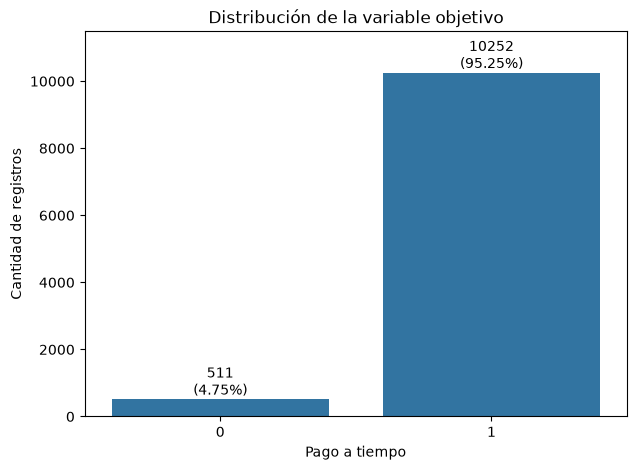

In [35]:
# ============================================================
# 8. Visualización de la distribución de la variable objetivo
# ============================================================
plt.figure(figsize=(7, 5))
ax = sns.countplot(
    data=df,
    x=target
)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Pago a tiempo")
plt.ylabel("Cantidad de registros")
for barra in ax.patches:
    cantidad = barra.get_height()
    porcentaje = cantidad / len(df) * 100

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        cantidad,
        f"{cantidad:.0f}\n({porcentaje:.2f}%)",
        ha="center",
        va="bottom"
    )
plt.ylim(0, df[target].value_counts().max() * 1.12)
plt.show()

### Interpretación de la variable objetivo

La variable objetivo `Pago_atiempo` presenta un fuerte desbalance entre clases. La clase `1`, correspondiente a clientes que pagaron a tiempo, concentra 10.252 registros, equivalentes al 95,25% del dataset. En cambio, la clase `0`, asociada a clientes que no pagaron a tiempo, cuenta con 511 registros, equivalentes al 4,75%.

Este desbalance es relevante porque, en etapas posteriores de modelado, una métrica como accuracy podría resultar engañosa. Un modelo que prediga mayoritariamente la clase dominante podría obtener una exactitud alta sin detectar correctamente los casos de incumplimiento. Por este motivo, será necesario evaluar los modelos con métricas adicionales como precision, recall, F1-score, matriz de confusión y ROC-AUC.

In [36]:
# ============================================================
# 9. Análisis de valores nulos
# ============================================================
resumen_nulos = pd.DataFrame({
    "columna": df.columns,
    "nulos": df.isnull().sum().values,
    "porcentaje_nulos": (df.isnull().mean().values * 100).round(2)
})
resumen_nulos = resumen_nulos[resumen_nulos["nulos"] > 0]
resumen_nulos = resumen_nulos.sort_values(by="porcentaje_nulos", ascending=False)
resumen_nulos

,columna,nulos,porcentaje_nulos
21,tendencia_ingresos,2932,27.24
20,promedio_ingresos_datacredito,2930,27.22
16,saldo_mora_codeudor,590,5.48
15,saldo_principal,405,3.76
13,saldo_mora,156,1.45
14,saldo_total,156,1.45
10,puntaje_datacredito,6,0.06


### Interpretación de valores nulos

El análisis de valores faltantes muestra que el dataset presenta nulos en un conjunto reducido de variables. Las columnas con mayor porcentaje de valores faltantes son `tendencia_ingresos` y `promedio_ingresos_datacredito`, ambas con aproximadamente un 27% de datos ausentes.

Estas variables podrían ser relevantes para el análisis crediticio, ya que están asociadas al comportamiento o capacidad económica del cliente. Por ese motivo, no se tomarán decisiones inmediatas de eliminación o imputación durante esta etapa exploratoria.

También se observan valores faltantes en variables relacionadas con saldos y mora, como `saldo_mora_codeudor`, `saldo_principal`, `saldo_mora` y `saldo_total`, aunque en menor proporción. Finalmente, `puntaje_datacredito` presenta una cantidad mínima de nulos.

En esta etapa, los valores faltantes se documentan como hallazgo del EDA. Su tratamiento será definido posteriormente durante la etapa de limpieza e ingeniería de características, evaluando el impacto de cada variable sobre el problema de predicción.

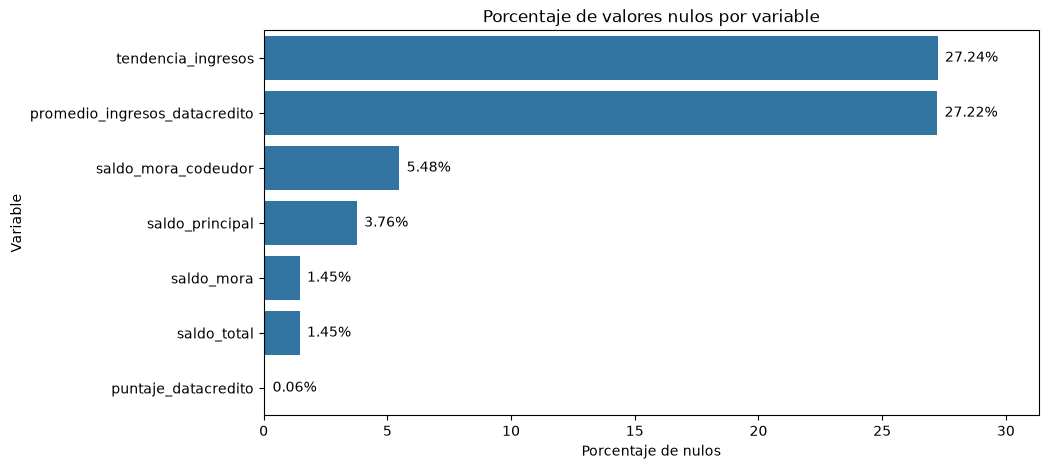

In [37]:
# ============================================================
# 10. Visualización de valores nulos
# ============================================================
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=resumen_nulos,
    x="porcentaje_nulos",
    y="columna"
)
plt.title("Porcentaje de valores nulos por variable")
plt.xlabel("Porcentaje de nulos")
plt.ylabel("Variable")
for barra in ax.patches:
    porcentaje = barra.get_width()

    ax.text(
        porcentaje + 0.3,
        barra.get_y() + barra.get_height() / 2,
        f"{porcentaje:.2f}%",
        va="center"
    )
plt.xlim(0, resumen_nulos["porcentaje_nulos"].max() * 1.15)
plt.show()

In [38]:
# ============================================================
# 11. Clasificación inicial de variables por tipo
# ============================================================
columnas_fecha = df.select_dtypes(include=["datetime64[ns]"]).columns.tolist()
columnas_numericas = df.select_dtypes(include=["number"]).columns.tolist()
if target in columnas_numericas:
    columnas_numericas.remove(target)
columnas_categoricas = df.select_dtypes(
    exclude=["number", "datetime64[ns]"]
).columns.tolist()
if target in columnas_categoricas:
    columnas_categoricas.remove(target)
print(f"Cantidad de variables numéricas predictoras: {len(columnas_numericas)}")
print(f"Cantidad de variables categóricas predictoras: {len(columnas_categoricas)}")
print(f"Cantidad de variables de fecha: {len(columnas_fecha)}")
print(f"Variable objetivo: {target}")
print("\nVariables numéricas predictoras:")
print(columnas_numericas)
print("\nVariables categóricas predictoras:")
print(columnas_categoricas)
print("\nVariables de fecha:")
print(columnas_fecha)

Cantidad de variables numéricas predictoras: 19
Cantidad de variables categóricas predictoras: 2
Cantidad de variables de fecha: 1
Variable objetivo: Pago_atiempo

Variables numéricas predictoras:
['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']

Variables categóricas predictoras:
['tipo_laboral', 'tendencia_ingresos']

Variables de fecha:
['fecha_prestamo']


### Interpretación de tipos de variables

El dataset contiene principalmente variables numéricas predictoras, junto con un conjunto reducido de variables categóricas y una variable de fecha.

Se identificaron 19 variables numéricas predictoras, 2 variables categóricas predictoras y 1 variable temporal (`fecha_prestamo`). La variable `Pago_atiempo` se separa del resto de columnas porque representa la variable objetivo del problema de clasificación.

Esta separación es importante porque las variables predictoras serán utilizadas posteriormente para construir el modelo, mientras que `Pago_atiempo` será la variable que el modelo intentará predecir.

También se observa que algunas variables numéricas, como `tipo_credito`, podrían representar códigos o categorías codificadas numéricamente. Por lo tanto, antes del modelado será necesario revisar su significado para decidir si deben tratarse como variables numéricas reales o como variables categóricas codificadas.

In [40]:
# ============================================================
# 12. Resumen estadístico de variables numéricas predictoras
# ============================================================
resumen_numericas = df[columnas_numericas].describe()
resumen_numericas.loc["rango"] = (
    resumen_numericas.loc["max"] - resumen_numericas.loc["min"]
)
resumen_numericas.loc["coef_variacion"] = (
    resumen_numericas.loc["std"] / resumen_numericas.loc["mean"]
)
resumen_numericas_formateado = resumen_numericas.copy().astype("object")
for fila in resumen_numericas.index:
    for columna in resumen_numericas.columns:

        valor = resumen_numericas.loc[fila, columna]

        if pd.isna(valor) or np.isinf(valor):
            resumen_numericas_formateado.loc[fila, columna] = "-"
        elif fila == "count":
            resumen_numericas_formateado.loc[fila, columna] = f"{valor:,.0f}"
        elif fila == "coef_variacion":
            resumen_numericas_formateado.loc[fila, columna] = f"{valor:.2f}"
        else:
            resumen_numericas_formateado.loc[fila, columna] = f"{valor:,.2f}"
resumen_numericas_formateado

,tipo_credito,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito
count,"10,763","10,763","10,763","10,763","10,763","10,763","10,763","10,763","10,757","10,763","10,763","10,607","10,607","10,358","10,173","10,763","10,763","10,763","7,833"
mean,5.41,"2,434,315.00",10.58,43.95,"17,216,431.46","6,238,869.65","243,617.41",91.17,780.79,5.73,4.23,7.75,"45,937.41","40,346.17",0.26,2.78,0.27,1.30,"2,005,156.81"
std,2.34,"1,909,642.76",6.63,15.06,"355,476,717.60","118,418,316.94","210,493.69",16.47,104.88,3.98,3.06,225.96,"106,269.79","71,242.44",21.77,2.75,0.72,1.82,"2,144,116.15"
min,4.00,"360,000.00",2.00,19.00,0.00,0.00,"23,944.00",-38.01,-7.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,4.00,"1,224,831.00",6.00,33.00,"2,000,000.00","500,000.00","121,041.50",95.23,757.00,3.00,2.00,0.00,"2,898.00","2,690.00",0.00,1.00,0.00,0.00,"925,157.00"
50%,4.00,"1,921,920.00",10.00,42.00,"3,000,000.00","1,000,000.00","182,863.00",95.23,791.00,5.00,4.00,0.00,"16,178.00","14,442.50",0.00,2.00,0.00,1.00,"1,204,496.00"
75%,9.00,"3,084,840.00",12.00,53.00,"4,875,808.00","2,000,000.00","287,833.50",95.23,825.00,8.00,6.00,0.00,"52,982.00","47,632.25",0.00,4.00,0.00,2.00,"2,231,859.00"
max,68.00,"41,444,152.80",90.00,123.00,"22,000,000,000.00","6,787,675,263.00","3,816,752.00",95.23,999.00,62.00,29.00,"12,534.00","5,116,066.00","1,562,285.00","2,145.00",51.00,13.00,25.00,"38,106,581.00"
rango,64.00,"41,084,152.80",88.00,104.00,"22,000,000,000.00","6,787,675,263.00","3,792,808.00",133.24,"1,006.00",62.00,29.00,"12,534.00","5,116,066.00","1,562,285.00","2,145.00",51.00,13.00,25.00,"38,106,581.00"
coef_variacion,0.43,0.78,0.63,0.34,20.65,18.98,0.86,0.18,0.13,0.69,0.72,29.17,2.31,1.77,83.74,0.99,2.66,1.40,1.07


### Interpretación del resumen estadístico numérico

El resumen estadístico permite observar la escala, dispersión y posibles valores extremos de las variables numéricas predictoras.

Se identifican variables monetarias con rangos muy amplios, como `salario_cliente`, `total_otros_prestamos`, `capital_prestado`, `cuota_pactada`, `saldo_total`, `saldo_principal` y `promedio_ingresos_datacredito`. Esta diferencia de escala será relevante más adelante, ya que algunos modelos pueden requerir escalamiento o transformaciones para mejorar su desempeño.

También se observan posibles valores atípicos o inconsistencias que deberán revisarse en etapas posteriores. Por ejemplo, `edad_cliente` presenta un valor máximo de 123 años, `puntaje` tiene un valor mínimo negativo y `puntaje_datacredito` presenta un mínimo de -7. Estos casos no se modifican en esta etapa, pero quedan documentados como hallazgos del análisis exploratorio.

El coeficiente de variación muestra alta dispersión en algunas variables, especialmente `saldo_mora_codeudor`, `saldo_mora`, `salario_cliente` y `total_otros_prestamos`. Esto indica que existen diferencias importantes entre clientes y posibles valores extremos que deberán analizarse con mayor detalle antes del modelado.

En esta etapa, el objetivo es comprender la distribución general de las variables numéricas, sin aplicar todavía limpieza, imputación ni transformación de datos.

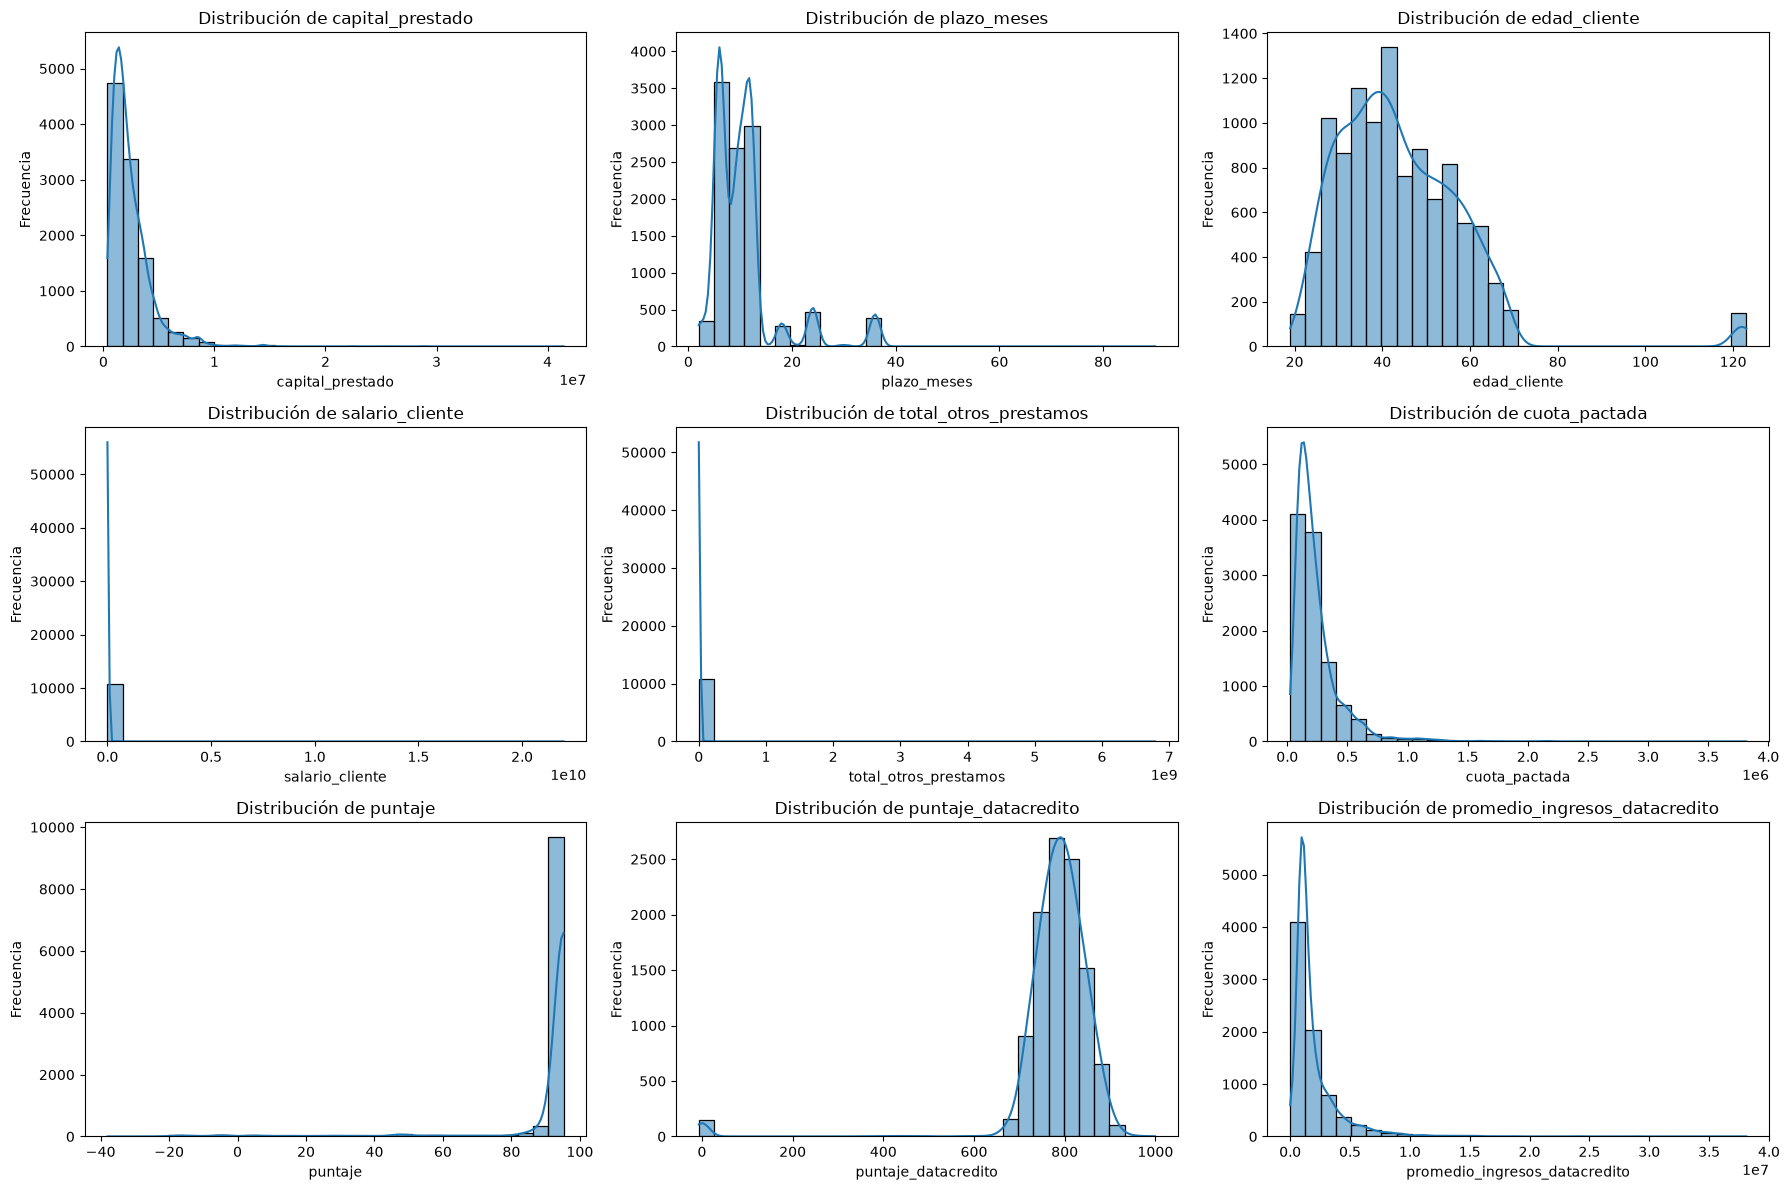

In [41]:
# ============================================================
# 13. Distribución de variables numéricas seleccionadas
# ============================================================
variables_numericas_clave = [
    "capital_prestado",
    "plazo_meses",
    "edad_cliente",
    "salario_cliente",
    "total_otros_prestamos",
    "cuota_pactada",
    "puntaje",
    "puntaje_datacredito",
    "promedio_ingresos_datacredito"
]
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, variable in enumerate(variables_numericas_clave):
    sns.histplot(
        data=df,
        x=variable,
        bins=30,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribución de {variable}")
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### Interpretación de distribuciones numéricas seleccionadas

Las distribuciones de las variables numéricas muestran comportamientos heterogéneos. Algunas variables monetarias, como `capital_prestado`, `cuota_pactada` y `promedio_ingresos_datacredito`, presentan una marcada asimetría hacia la derecha, lo que indica que la mayoría de los registros se concentran en valores bajos o medios, mientras que existen pocos casos con valores considerablemente altos.

También se observan variables con posibles valores extremos, especialmente `salario_cliente`, `total_otros_prestamos`, `edad_cliente`, `puntaje` y `puntaje_datacredito`. Estos casos no se modifican en esta etapa, pero quedan documentados como hallazgos relevantes del análisis exploratorio.

La variable `plazo_meses` presenta concentraciones en ciertos valores específicos, lo cual puede ser coherente con productos crediticios que se ofrecen en plazos definidos. Por otra parte, `puntaje` se encuentra fuertemente concentrado en valores altos, aunque presenta registros con valores bajos o negativos que deberán revisarse posteriormente.

En esta etapa no se aplican transformaciones ni limpieza de datos. El objetivo es identificar patrones generales, posibles asimetrías y valores atípicos que serán evaluados más adelante durante la etapa de ingeniería de características.

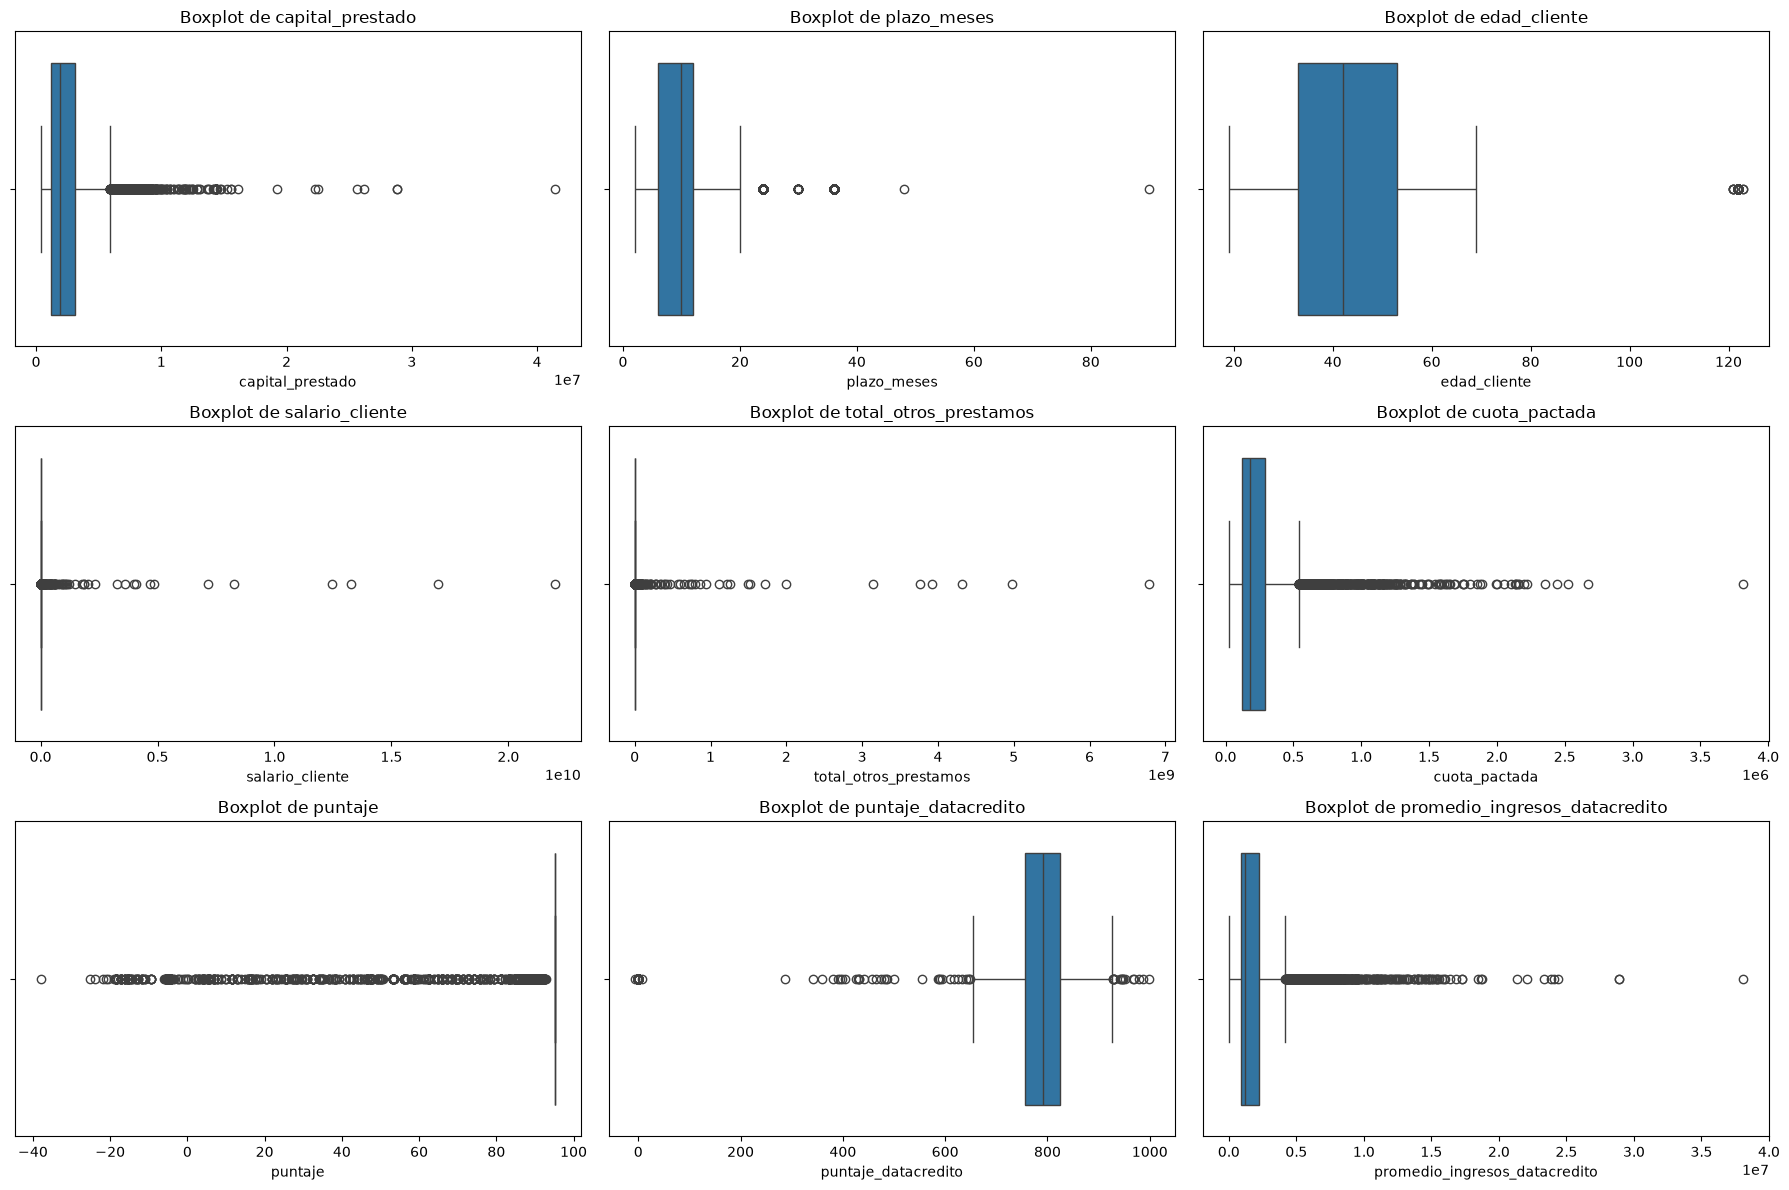

In [42]:
# ============================================================
# 14. Boxplots de variables numéricas seleccionadas
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, variable in enumerate(variables_numericas_clave):
    sns.boxplot(
        data=df,
        x=variable,
        ax=axes[i]
    )
    axes[i].set_title(f"Boxplot de {variable}")
    axes[i].set_xlabel(variable)
plt.tight_layout()
plt.show()

### Interpretación de boxplots de variables numéricas seleccionadas

Los boxplots permiten observar con mayor claridad la presencia de posibles valores atípicos en las variables numéricas seleccionadas.

Las variables monetarias como `capital_prestado`, `salario_cliente`, `total_otros_prestamos`, `cuota_pactada` y `promedio_ingresos_datacredito` presentan valores extremos hacia la derecha. Esto indica que la mayoría de los clientes se concentra en rangos más bajos o medios, mientras que existen algunos registros con montos considerablemente superiores.

También se observan posibles valores atípicos en `edad_cliente`, donde aparecen registros cercanos a 120 años, y en las variables de puntaje, especialmente `puntaje` y `puntaje_datacredito`, donde existen valores muy bajos o incluso negativos.

En esta etapa no se eliminan ni modifican estos registros. Los valores atípicos quedan documentados como hallazgos del EDA y deberán analizarse posteriormente durante la etapa de limpieza e ingeniería de características, evaluando si representan errores, casos reales extremos o información útil para el modelo.

In [43]:
# ============================================================
# 15. Distribución de variables categóricas
# ============================================================
for variable in columnas_categoricas:
    print(f"\nDistribución de la variable: {variable}")
    
    distribucion_categoria = (
        df[variable]
        .value_counts(dropna=False)
        .reset_index()
    )
    distribucion_categoria.columns = [variable, "cantidad"]
    distribucion_categoria["porcentaje"] = (
        distribucion_categoria["cantidad"] / len(df) * 100
    ).round(2)
    display(distribucion_categoria)


Distribución de la variable: tipo_laboral


,tipo_laboral,cantidad,porcentaje
0,Empleado,6754,62.75
1,Independiente,4009,37.25



Distribución de la variable: tendencia_ingresos


,tendencia_ingresos,cantidad,porcentaje
0,Creciente,5294,49.19
1,NaN,2932,27.24
2,Decreciente,1291,11.99
3,Estable,1188,11.04
4,0,7,0.07
5,8315,6,0.06
6,1000000,4,0.04
7,9147,2,0.02
8,158042,1,0.01
9,3978,1,0.01


### Interpretación de variables categóricas

El análisis univariable de variables categóricas muestra que `tipo_laboral` presenta dos categorías principales: `Empleado` e `Independiente`. La mayor parte de los registros corresponde a clientes empleados, mientras que el resto pertenece a clientes independientes.

En el caso de `tendencia_ingresos`, se observa un hallazgo relevante: además de las categorías esperadas (`Creciente`, `Decreciente` y `Estable`) y valores nulos, aparecen valores numéricos dentro de la misma columna. Esto sugiere una posible inconsistencia en la carga o representación de los datos.

Este hallazgo no se corrige en esta etapa exploratoria. La columna queda documentada para ser revisada posteriormente durante la etapa de limpieza e ingeniería de características, donde se deberá decidir si estos valores numéricos representan errores, datos mal cargados o información que debe reclasificarse.

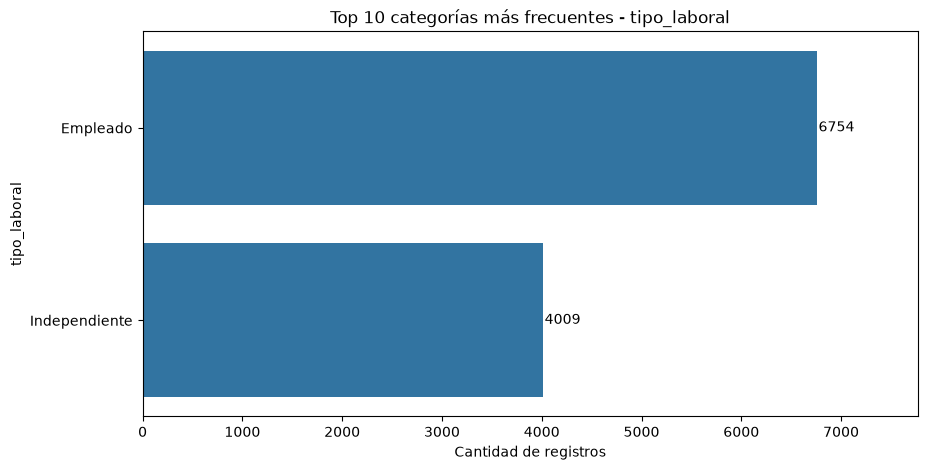

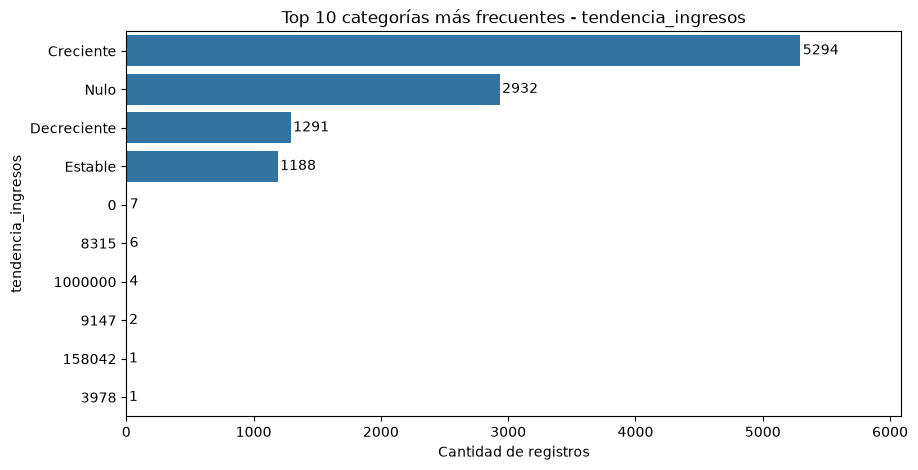

In [44]:
# ============================================================
# 16. Visualización de variables categóricas
# ============================================================
for variable in columnas_categoricas:
    datos_categoria = (
        df[variable]
        .fillna("Nulo")
        .astype(str)
        .value_counts()
        .head(10)
        .reset_index()
    )
    datos_categoria.columns = [variable, "cantidad"]
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=datos_categoria,
        x="cantidad",
        y=variable
    )
    plt.title(f"Top 10 categorías más frecuentes - {variable}")
    plt.xlabel("Cantidad de registros")
    plt.ylabel(variable)
    for barra in ax.patches:
        cantidad = barra.get_width()
        ax.text(
            cantidad + 20,
            barra.get_y() + barra.get_height() / 2,
            f"{cantidad:.0f}",
            va="center"
        )
    plt.xlim(0, datos_categoria["cantidad"].max() * 1.15)
    plt.show()

### Interpretación visual de variables categóricas

La visualización de variables categóricas confirma que `tipo_laboral` presenta una estructura simple y consistente, compuesta únicamente por las categorías `Empleado` e `Independiente`.

En cambio, `tendencia_ingresos` muestra una situación más compleja. Las categorías principales son `Creciente`, `Decreciente`, `Estable` y valores nulos. Sin embargo, también aparecen registros numéricos dentro de una variable que conceptualmente debería ser categórica.

Este comportamiento refuerza la necesidad de revisar esta columna en una etapa posterior de limpieza o ingeniería de características. Por el momento, el hallazgo queda documentado dentro del EDA, sin realizar modificaciones sobre el dataset original.

In [45]:
# ============================================================
# 17. Relación entre variables categóricas y variable objetivo
# ============================================================
for variable in columnas_categoricas:
    print(f"\nRelación entre {variable} y {target}")
    tabla_bivariada = (
        df.assign(**{variable: df[variable].fillna("Nulo").astype(str)})
        .groupby([variable, target])
        .size()
        .reset_index(name="cantidad")
    )
    tabla_bivariada["porcentaje_dentro_categoria"] = (
        tabla_bivariada["cantidad"]
        / tabla_bivariada.groupby(variable)["cantidad"].transform("sum")
        * 100
    ).round(2)
    display(tabla_bivariada)


Relación entre tipo_laboral y Pago_atiempo


,tipo_laboral,Pago_atiempo,cantidad,porcentaje_dentro_categoria
0,Empleado,0,290,4.29
1,Empleado,1,6464,95.71
2,Independiente,0,221,5.51
3,Independiente,1,3788,94.49



Relación entre tendencia_ingresos y Pago_atiempo


,tendencia_ingresos,Pago_atiempo,cantidad,porcentaje_dentro_categoria
0,-101368,1,1,100.00
1,-164315,1,1,100.00
2,-224714,1,1,100.00
3,-28589,1,1,100.00
4,-288,1,1,100.00
5,-4105,1,1,100.00
6,-435177,1,1,100.00
7,-566272,1,1,100.00
8,-702927,1,1,100.00
9,-70715,1,1,100.00


### Criterio para el análisis bivariado categórico

En esta etapa se analiza la relación entre las variables categóricas predictoras y la variable objetivo `Pago_atiempo`.

Se utilizan `tipo_laboral` y `tendencia_ingresos` porque son las variables identificadas previamente como categóricas dentro del dataset. El objetivo es observar si la proporción de clientes que pagan o no pagan a tiempo cambia según la categoría de cada variable.

Para `tipo_laboral`, se consideran todas sus categorías, ya que presenta una estructura consistente compuesta por `Empleado` e `Independiente`.

En el caso de `tendencia_ingresos`, se detectaron valores inconsistentes de tipo numérico dentro de una variable que conceptualmente debería ser categórica. Por este motivo, para la tabla cruzada y el heatmap se consideran únicamente las categorías interpretables principales: `Creciente`, `Decreciente`, `Estable` y `Nulo`.

Esta decisión no implica una limpieza definitiva del dato. Solo se realiza para que el análisis visual sea interpretable durante el EDA. El tratamiento formal de los valores inconsistentes se definirá más adelante en la etapa de limpieza e ingeniería de características.


Tabla cruzada porcentual: tipo_laboral vs Pago_atiempo


Pago_atiempo,0,1
tipo_laboral,,
Empleado,4.29,95.71
Independiente,5.51,94.49


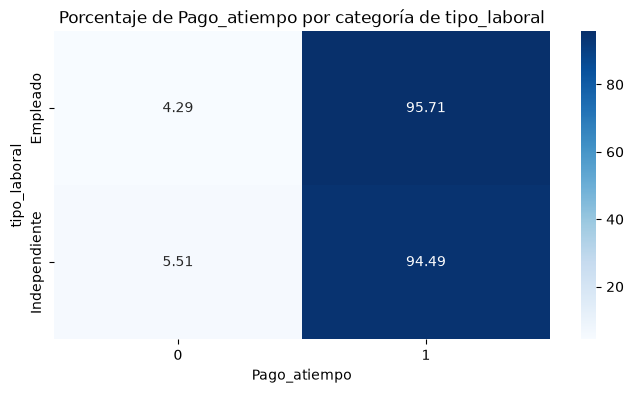


Tabla cruzada porcentual: tendencia_ingresos vs Pago_atiempo


Pago_atiempo,0,1
tendencia_ingresos,,
Creciente,3.91,96.09
Decreciente,6.27,93.73
Estable,4.63,95.37
Nulo,5.73,94.27


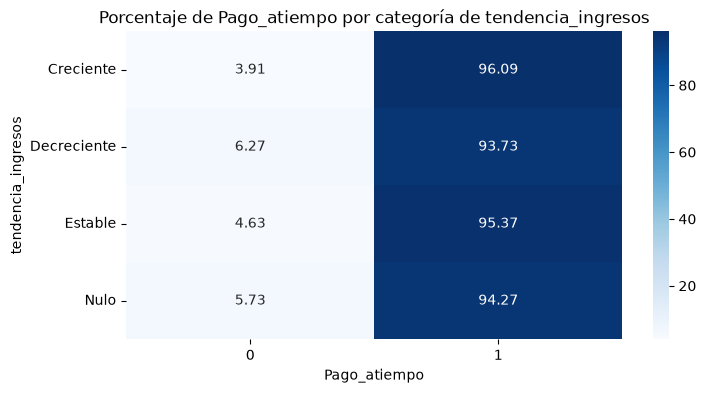

In [46]:
# ============================================================
# 18. Tabla cruzada porcentual entre variables categóricas y target
# ============================================================
categorias_validas_tendencia = ["Creciente", "Decreciente", "Estable", "Nulo"]
for variable in columnas_categoricas:
    datos_temp = df[[variable, target]].copy()
    datos_temp[variable] = datos_temp[variable].fillna("Nulo").astype(str)
    if variable == "tendencia_ingresos":
        datos_temp = datos_temp[
            datos_temp[variable].isin(categorias_validas_tendencia)
        ]
    tabla_cruzada = pd.crosstab(
        datos_temp[variable],
        datos_temp[target],
        normalize="index"
    ) * 100
    tabla_cruzada = tabla_cruzada.round(2)
    print(f"\nTabla cruzada porcentual: {variable} vs {target}")
    display(tabla_cruzada)
    plt.figure(figsize=(8, 4))
    sns.heatmap(
        tabla_cruzada,
        annot=True,
        fmt=".2f",
        cmap="Blues"
    )
    plt.title(f"Porcentaje de {target} por categoría de {variable}")
    plt.xlabel(target)
    plt.ylabel(variable)
    plt.show()

### Interpretación de tablas cruzadas y heatmaps categóricos

Las tablas cruzadas porcentuales y los heatmaps permiten analizar cómo se distribuye la variable objetivo `Pago_atiempo` dentro de cada categoría de las variables categóricas.

En `tipo_laboral`, se observa que tanto los clientes `Empleado` como `Independiente` presentan una proporción alta de pagos a tiempo. Los empleados registran un 95,71% de pagos a tiempo, mientras que los independientes presentan un 94,49%. La diferencia entre ambos grupos existe, pero no parece ser muy marcada en esta primera observación exploratoria.

En `tendencia_ingresos`, considerando únicamente las categorías interpretables principales, también se mantiene una alta proporción de pagos a tiempo en todos los grupos. La categoría `Creciente` presenta el mayor porcentaje de pagos a tiempo, con 96,09%, mientras que `Decreciente` muestra un porcentaje menor, con 93,73%. Los registros `Nulo` presentan un 94,27% de pagos a tiempo.

Estos resultados deben interpretarse con cautela debido al fuerte desbalance de la variable objetivo. Como la mayoría de los clientes pagó a tiempo, todas las categorías tienden a mostrar porcentajes elevados para la clase `1`.

En esta etapa no se concluye causalidad ni se toman decisiones de transformación. El objetivo es identificar posibles relaciones iniciales entre variables categóricas y el target, que luego podrán ser evaluadas con mayor profundidad durante el modelado.

In [48]:
# ============================================================
# 19. Resumen de variables numéricas según variable objetivo
# ============================================================
filas_resumen = []
for clase in sorted(df[target].dropna().unique()):
    for variable in variables_numericas_clave:
        serie = df.loc[df[target] == clase, variable]
        filas_resumen.append({
            target: clase,
            "variable": variable,
            "media": serie.mean(),
            "mediana": serie.median(),
            "desvio_estandar": serie.std()
        })
resumen_numericas_target = pd.DataFrame(filas_resumen)
resumen_numericas_target["media"] = resumen_numericas_target["media"].round(2)
resumen_numericas_target["mediana"] = resumen_numericas_target["mediana"].round(2)
resumen_numericas_target["desvio_estandar"] = resumen_numericas_target["desvio_estandar"].round(2)
resumen_numericas_target

,Pago_atiempo,variable,media,mediana,desvio_estandar
0,0,capital_prestado,"2,781,774.11","2,268,000.00","1,942,337.70"
1,0,plazo_meses,12.45,10.00,9.27
2,0,edad_cliente,41.77,38.00,17.06
3,0,salario_cliente,"23,555,143.33","3,000,000.00","274,787,635.68"
4,0,total_otros_prestamos,"11,564,401.93","900,000.00","178,148,935.52"
5,0,cuota_pactada,"254,755.69","199,002.00","201,712.00"
6,0,puntaje,23.09,25.42,26.07
7,0,puntaje_datacredito,748.88,768.00,130.91
8,0,promedio_ingresos_datacredito,"1,605,742.05","1,052,529.00","1,668,892.06"
9,1,capital_prestado,"2,416,996.27","1,908,446.40","1,906,438.41"


### Interpretación del resumen numérico según la variable objetivo

El resumen de variables numéricas según `Pago_atiempo` permite comparar el comportamiento promedio de distintos grupos de clientes.

Se observa que los clientes que no pagaron a tiempo (`Pago_atiempo = 0`) presentan, en promedio, mayores valores de `capital_prestado`, `plazo_meses`, `salario_cliente`, `total_otros_prestamos` y `cuota_pactada`. Esto podría sugerir que ciertos niveles de endeudamiento, monto solicitado o duración del crédito pueden estar asociados a mayor riesgo de incumplimiento.

Por otro lado, los clientes que pagaron a tiempo (`Pago_atiempo = 1`) presentan valores promedio más altos en `puntaje`, `puntaje_datacredito` y `promedio_ingresos_datacredito`. En particular, la diferencia observada en `puntaje` es considerable, lo que sugiere que esta variable podría tener una relación importante con el comportamiento de pago.

Estos resultados son exploratorios y no implican causalidad. Además, debido al fuerte desbalance de la variable objetivo, las comparaciones deben interpretarse con cautela. En etapas posteriores será necesario evaluar estas variables dentro de modelos supervisados y con métricas adecuadas.

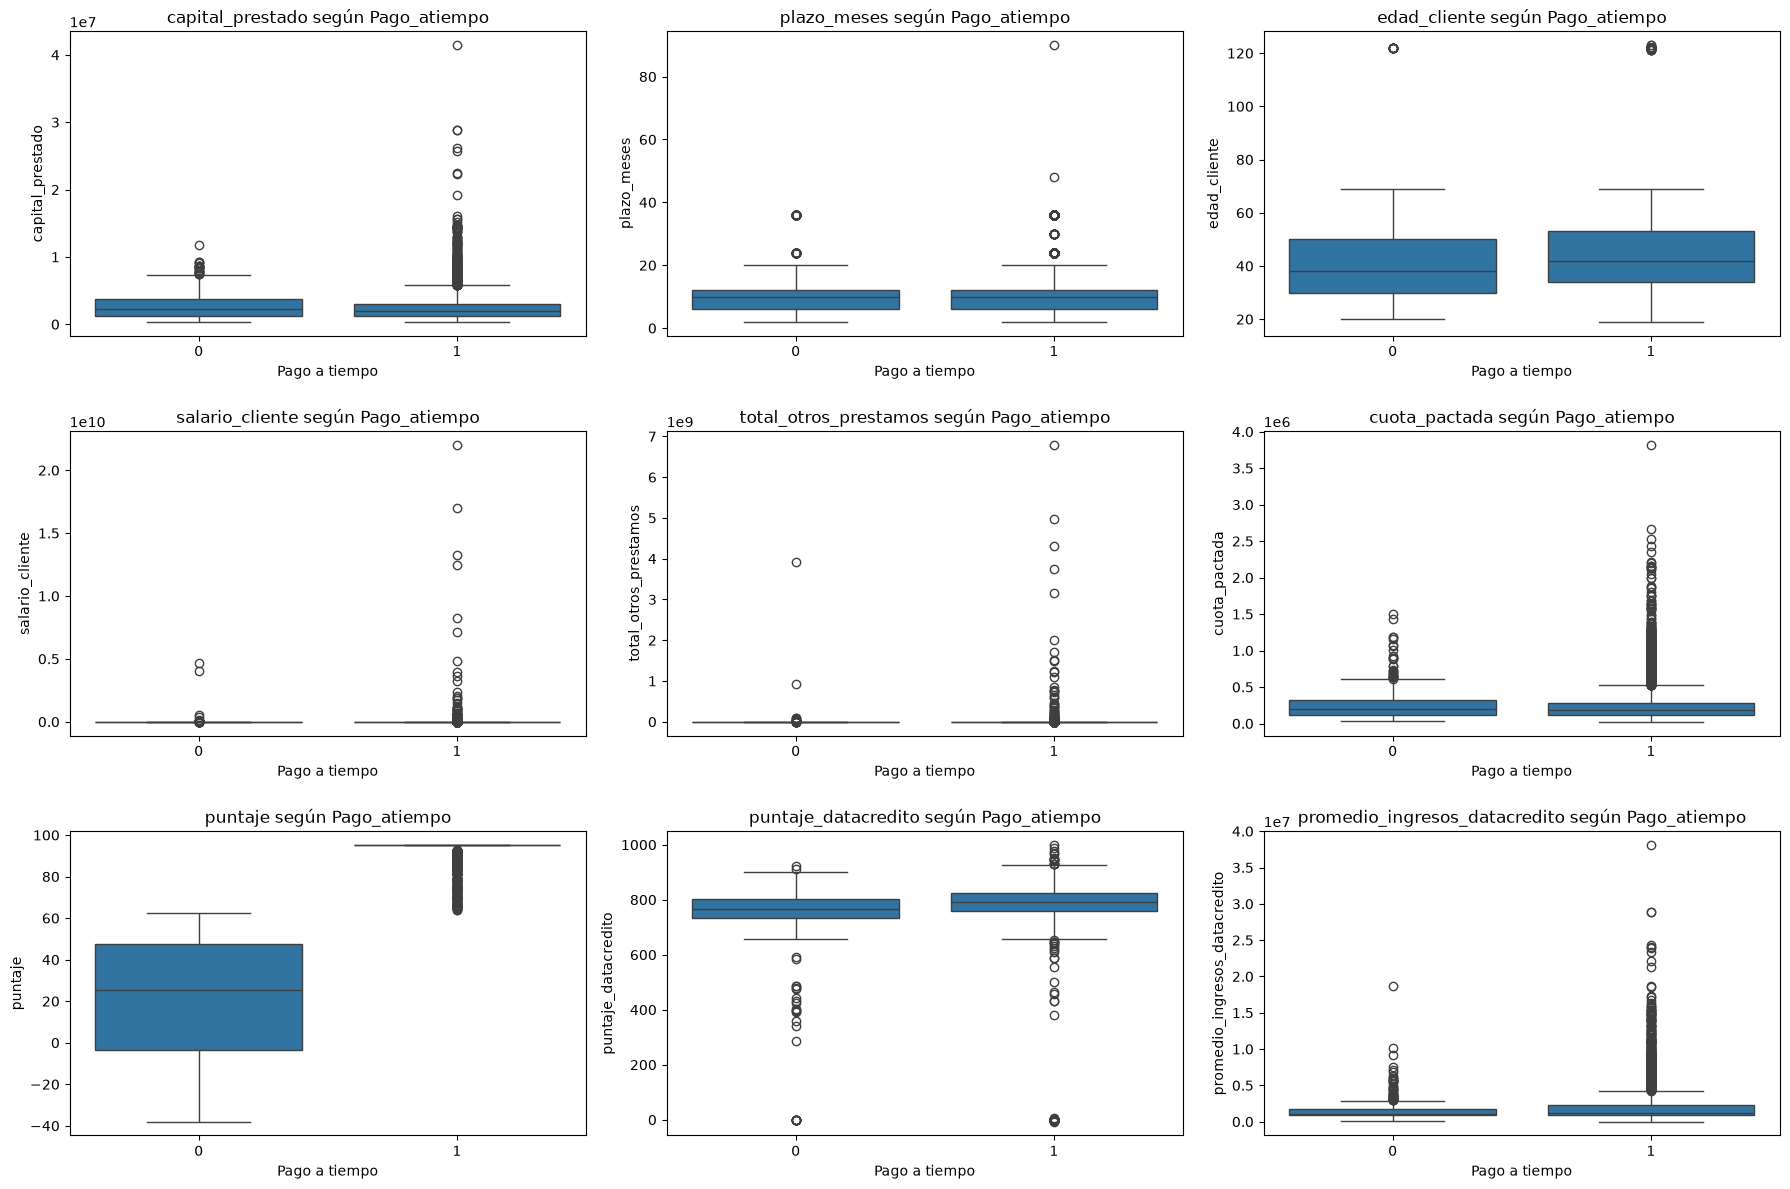

In [49]:
# ============================================================
# 20. Boxplots de variables numéricas según variable objetivo
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, variable in enumerate(variables_numericas_clave):
    sns.boxplot(
        data=df,
        x=target,
        y=variable,
        ax=axes[i]
    )
    axes[i].set_title(f"{variable} según {target}")
    axes[i].set_xlabel("Pago a tiempo")
    axes[i].set_ylabel(variable)
plt.tight_layout()
plt.show()

### Interpretación de boxplots numéricos según la variable objetivo

Los boxplots permiten comparar visualmente la distribución de las variables numéricas entre los clientes que no pagaron a tiempo (`Pago_atiempo = 0`) y los que sí pagaron a tiempo (`Pago_atiempo = 1`).

Se observa una diferencia marcada en la variable `puntaje`. Los clientes que no pagaron a tiempo presentan valores considerablemente más bajos y dispersos, mientras que los clientes que sí pagaron a tiempo se concentran en valores altos. Esto sugiere que `puntaje` podría ser una variable relevante para distinguir entre ambos grupos.

También se observan diferencias en `puntaje_datacredito`, donde los clientes que pagaron a tiempo tienden a presentar valores algo superiores. En variables monetarias como `capital_prestado`, `cuota_pactada`, `salario_cliente`, `total_otros_prestamos` y `promedio_ingresos_datacredito`, se identifican valores extremos en ambos grupos, lo que dificulta la lectura directa de los gráficos.

La presencia de outliers es especialmente visible en variables monetarias y de ingresos. Estos valores no se modifican en esta etapa, pero quedan documentados como posibles puntos a revisar durante la limpieza e ingeniería de características.

Estos resultados son exploratorios y deben interpretarse con cautela debido al fuerte desbalance de la variable objetivo.

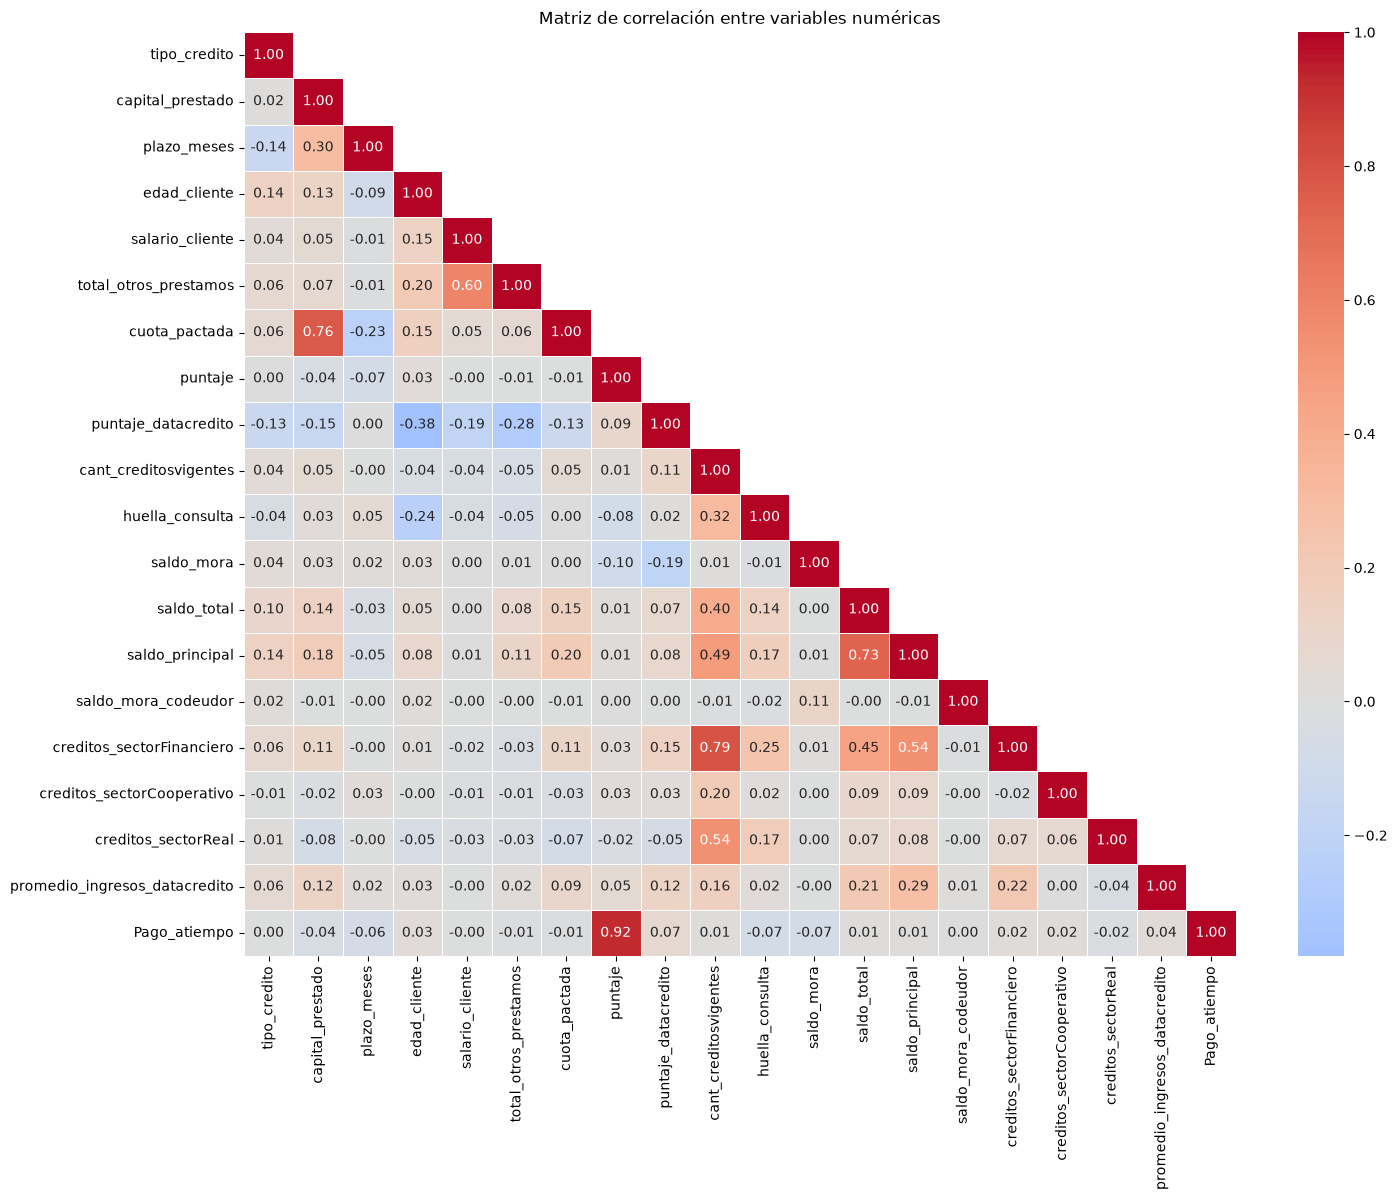

In [51]:
# ============================================================
# 21. Matriz de correlación de variables numéricas
# ============================================================
columnas_correlacion = columnas_numericas + [target]
matriz_correlacion = df[columnas_correlacion].corr(numeric_only=True)
mascara = np.triu(
    np.ones_like(matriz_correlacion, dtype=bool),
    k=1
)
plt.figure(figsize=(16, 12))
sns.heatmap(
    matriz_correlacion,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

### Interpretación de la matriz de correlación

La matriz de correlación permite observar relaciones lineales entre variables numéricas del dataset.

El hallazgo más relevante es la alta correlación positiva entre `puntaje` y la variable objetivo `Pago_atiempo`, con un valor aproximado de 0.92. Esto sugiere que `puntaje` podría tener una relación muy fuerte con el comportamiento de pago. Sin embargo, esta variable deberá revisarse cuidadosamente en etapas posteriores, ya que una correlación tan elevada puede indicar una variable muy predictiva o una posible dependencia demasiado cercana al resultado que se busca predecir.

También se observan correlaciones altas entre algunas variables predictoras, como `capital_prestado` y `cuota_pactada`, `saldo_total` y `saldo_principal`, y `cant_creditosvigentes` con `creditos_sectorFinanciero`. Estas relaciones pueden ser esperables desde el punto de vista financiero, ya que algunas variables representan conceptos relacionados entre sí.

La mayoría de las variables numéricas presenta una correlación lineal baja con `Pago_atiempo`. Esto no significa necesariamente que no sean útiles para el modelo, ya que pueden existir relaciones no lineales o interacciones entre variables que serán evaluadas posteriormente durante la etapa de modelado.

En esta etapa no se eliminan variables ni se toman decisiones de selección. La matriz se utiliza únicamente como herramienta exploratoria para identificar relaciones iniciales, posibles redundancias y variables que requieren revisión posterior.

In [57]:
# ============================================================
# 22. Correlación de variables numéricas con la variable objetivo
# ============================================================
correlacion_target = (
    matriz_correlacion[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
    .reset_index()
)
correlacion_target.columns = ["variable", "correlacion_con_target"]
correlacion_target["correlacion_con_target"] = (
    correlacion_target["correlacion_con_target"].round(2)
)
correlacion_target

,variable,correlacion_con_target
0,puntaje,0.92
1,huella_consulta,-0.07
2,saldo_mora,-0.07
3,puntaje_datacredito,0.07
4,plazo_meses,-0.06
5,capital_prestado,-0.04
6,promedio_ingresos_datacredito,0.04
7,edad_cliente,0.03
8,creditos_sectorReal,-0.02
9,creditos_sectorFinanciero,0.02


### Interpretación de correlación con la variable objetivo

La correlación individual de las variables numéricas con `Pago_atiempo` muestra que `puntaje` es la variable con mayor relación lineal con el target, alcanzando una correlación aproximada de 0.92.

El resto de las variables presenta correlaciones bajas con la variable objetivo. Algunas variables como `huella_consulta`, `saldo_mora`, `puntaje_datacredito` y `plazo_meses` muestran relaciones leves, pero muy alejadas de la magnitud observada en `puntaje`.

Este resultado debe interpretarse con cautela. Una correlación baja no implica que una variable sea inútil para el modelo, ya que pueden existir relaciones no lineales, interacciones entre variables o patrones que modelos más complejos podrían capturar.

Por otro lado, la correlación tan elevada de `puntaje` con `Pago_atiempo` requiere una revisión posterior para evaluar si se trata de una variable genuinamente predictiva o si podría estar demasiado asociada al resultado final. En esta etapa no se elimina ni modifica ninguna variable; solo se documenta el hallazgo.

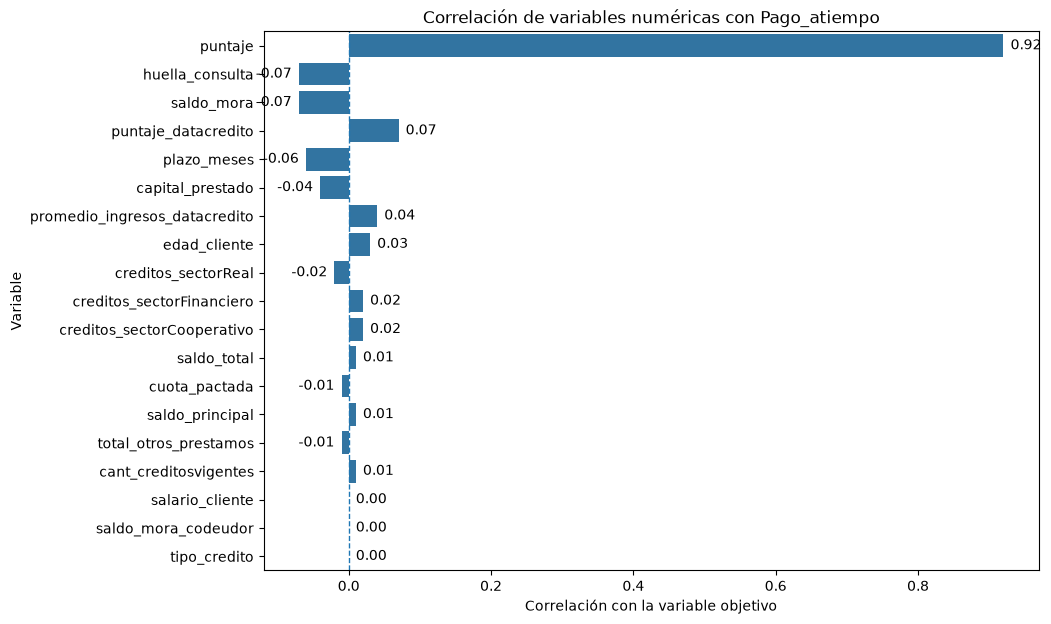

In [58]:
# ============================================================
# 23. Visualización de correlaciones con la variable objetivo
# ============================================================
plt.figure(figsize=(10, 7))
ax = sns.barplot(
    data=correlacion_target,
    x="correlacion_con_target",
    y="variable"
)
plt.title("Correlación de variables numéricas con Pago_atiempo")
plt.xlabel("Correlación con la variable objetivo")
plt.ylabel("Variable")
plt.axvline(0, linestyle="--", linewidth=1)
for barra in ax.patches:
    valor = barra.get_width()
    ax.text(
        valor + 0.01 if valor >= 0 else valor - 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.2f}",
        va="center",
        ha="left" if valor >= 0 else "right"
    )
plt.show()

### Interpretación visual de correlaciones con la variable objetivo

El gráfico de correlaciones permite visualizar de forma más clara la relación lineal entre cada variable numérica y la variable objetivo `Pago_atiempo`.

Se observa que `puntaje` presenta una correlación positiva muy superior al resto de las variables, con un valor aproximado de 0.92. Esto refuerza el hallazgo detectado previamente en la matriz de correlación y sugiere que esta variable podría tener un peso importante en la predicción del pago a tiempo.

El resto de las variables numéricas presenta correlaciones cercanas a cero, tanto positivas como negativas. Esto indica que, de manera individual y bajo una relación lineal simple, no muestran una asociación fuerte con el target.

Sin embargo, estas variables no deben descartarse en esta etapa. Una baja correlación lineal no implica necesariamente baja utilidad predictiva, ya que pueden existir relaciones no lineales, interacciones entre variables o patrones que sean capturados por modelos más complejos.

La variable `puntaje` deberá ser revisada con especial atención en etapas posteriores, ya que su alta correlación con el target podría representar una señal predictiva muy fuerte o una posible variable con riesgo de fuga de información.

In [59]:
# ============================================================
# 24. Análisis temporal inicial de fecha_prestamo
# ============================================================
fecha_minima = df["fecha_prestamo"].min()
fecha_maxima = df["fecha_prestamo"].max()
print(f"Fecha mínima de préstamo: {fecha_minima}")
print(f"Fecha máxima de préstamo: {fecha_maxima}")
prestamos_por_año = (
    df["fecha_prestamo"]
    .dt.year
    .value_counts()
    .sort_index()
    .reset_index()
)
prestamos_por_año.columns = ["año", "cantidad_prestamos"]
prestamos_por_año

Fecha mínima de préstamo: 2024-11-26 09:17:04
Fecha máxima de préstamo: 2026-04-26 18:43:52


,año,cantidad_prestamos
0,2024,1402
1,2025,9107
2,2026,254


### Interpretación del análisis temporal inicial

La variable `fecha_prestamo` permite analizar la distribución temporal de los créditos registrados en el dataset.

El rango de fechas observado va desde el 26 de noviembre de 2024 hasta el 26 de abril de 2026. Esto indica que la base contiene información de un período aproximado de un año y cinco meses.

Al agrupar los préstamos por año, se observa que la mayor concentración de registros corresponde al año 2025, con 9.107 préstamos. En cambio, 2024 presenta 1.402 registros y 2026 cuenta con 254 registros.

Esta diferencia se explica porque 2024 y 2026 no aparecen como años completos dentro del dataset: la base comienza hacia fines de 2024 y finaliza en abril de 2026. Por este motivo, las comparaciones temporales por año deben interpretarse con cautela.

En esta etapa no se realizan transformaciones sobre la fecha. El objetivo es comprender el rango temporal de los datos y detectar posibles concentraciones o períodos incompletos.

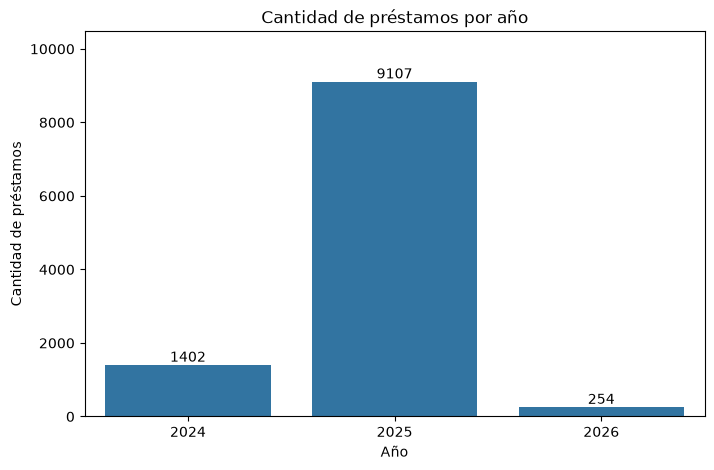

In [60]:
# ============================================================
# 25. Visualización de préstamos por año
# ============================================================
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=prestamos_por_año,
    x="año",
    y="cantidad_prestamos"
)
plt.title("Cantidad de préstamos por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de préstamos")
for barra in ax.patches:
    cantidad = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        cantidad,
        f"{cantidad:.0f}",
        ha="center",
        va="bottom"
    )
plt.ylim(0, prestamos_por_año["cantidad_prestamos"].max() * 1.15)
plt.show()

### Interpretación visual de préstamos por año

El gráfico de préstamos por año confirma que la mayor parte de los registros se concentra en 2025, con 9.107 préstamos.

Los años 2024 y 2026 presentan menor cantidad de registros, pero esto no necesariamente indica menor actividad crediticia anual, ya que ambos períodos están incompletos dentro del dataset. La base inicia en noviembre de 2024 y finaliza en abril de 2026.

Por este motivo, el año 2025 representa el período más completo para observar el comportamiento general de la cartera. En cambio, las comparaciones directas entre años deben realizarse con cautela para evitar interpretaciones erróneas.

In [61]:
# ============================================================
# 26. Cantidad de préstamos por mes
# ============================================================
prestamos_por_mes = (
    df
    .assign(año_mes=df["fecha_prestamo"].dt.to_period("M").astype(str))
    .groupby("año_mes")
    .size()
    .reset_index(name="cantidad_prestamos")
)
prestamos_por_mes

,año_mes,cantidad_prestamos
0,2024-11,186
1,2024-12,1216
2,2025-01,1917
3,2025-02,1094
4,2025-03,1115
5,2025-04,1102
6,2025-05,1083
7,2025-06,665
8,2025-07,644
9,2025-08,555


### Interpretación de préstamos por mes

El análisis mensual permite observar con mayor detalle la evolución temporal de los préstamos dentro del dataset.

Se identifica una mayor concentración de préstamos entre diciembre de 2024 y mayo de 2025, con un pico importante en enero de 2025. Luego, a partir de junio de 2025, la cantidad mensual de préstamos disminuye progresivamente.

Esta tendencia puede deberse a cambios operativos, estacionalidad, variaciones en la política crediticia, disponibilidad de datos o a la forma en que fue construido el dataset. En esta etapa no se asume una causa específica, sino que se documenta el patrón temporal observado.

El análisis mensual resulta más informativo que el análisis anual, ya que los años 2024 y 2026 se encuentran incompletos dentro de la base.

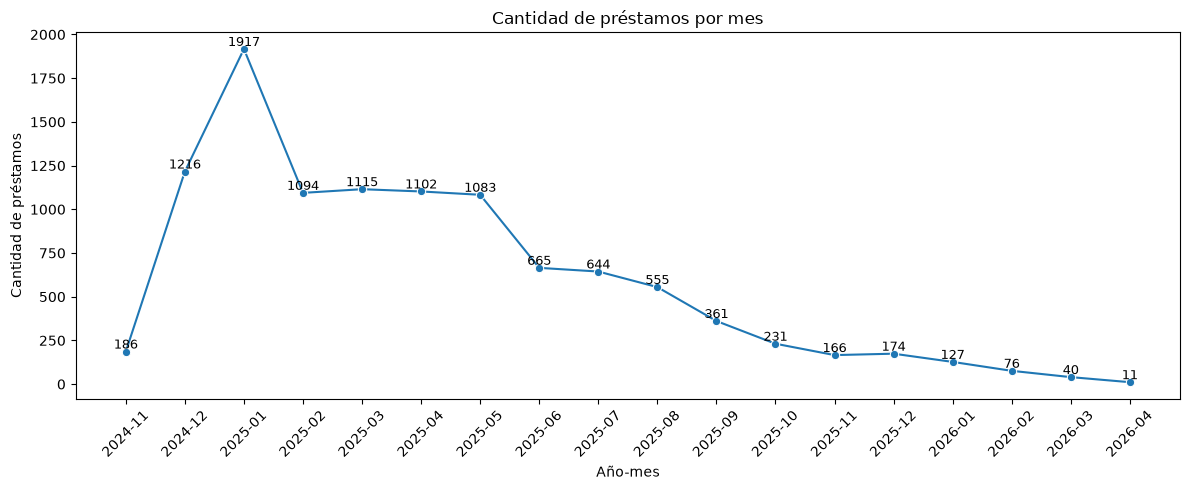

In [62]:
# ============================================================
# 27. Visualización de préstamos por mes
# ============================================================
plt.figure(figsize=(12, 5))
ax = sns.lineplot(
    data=prestamos_por_mes,
    x="año_mes",
    y="cantidad_prestamos",
    marker="o"
)
plt.title("Cantidad de préstamos por mes")
plt.xlabel("Año-mes")
plt.ylabel("Cantidad de préstamos")
plt.xticks(rotation=45)
for x, y in zip(prestamos_por_mes["año_mes"], prestamos_por_mes["cantidad_prestamos"]):
    ax.text(
        x,
        y,
        str(y),
        ha="center",
        va="bottom",
        fontsize=9
    )
plt.tight_layout()
plt.show()

### Interpretación visual de préstamos por mes

El gráfico mensual muestra una concentración inicial de préstamos entre diciembre de 2024 y mayo de 2025, con un pico máximo en enero de 2025, donde se registran 1.917 préstamos.

A partir de junio de 2025 se observa una disminución sostenida en la cantidad mensual de préstamos. Esta caída continúa durante los meses siguientes, llegando a valores muy bajos hacia 2026.

Este comportamiento temporal debe interpretarse con cautela. Puede deberse a cambios en la generación de datos, políticas crediticias, disponibilidad de información, estacionalidad o a la forma en que fue construido el dataset.

Por el momento no se realiza ninguna transformación temporal. El hallazgo queda documentado como parte del EDA y podría ser relevante en etapas posteriores, especialmente si se decide crear variables derivadas a partir de la fecha del préstamo.

In [63]:
# ============================================================
# 28. Proporción de pago a tiempo por mes
# ============================================================
pago_por_mes = (
    df
    .assign(anio_mes=df["fecha_prestamo"].dt.to_period("M").astype(str))
    .groupby(["anio_mes", target])
    .size()
    .reset_index(name="cantidad")
)
pago_por_mes["porcentaje_dentro_mes"] = (
    pago_por_mes["cantidad"]
    / pago_por_mes.groupby("anio_mes")["cantidad"].transform("sum")
    * 100
).round(2)
pago_por_mes

,anio_mes,Pago_atiempo,cantidad,porcentaje_dentro_mes
0,2024-11,0,13,6.99
1,2024-11,1,173,93.01
2,2024-12,0,74,6.09
3,2024-12,1,1142,93.91
4,2025-01,0,86,4.49
5,2025-01,1,1831,95.51
6,2025-02,0,64,5.85
7,2025-02,1,1030,94.15
8,2025-03,0,57,5.11
9,2025-03,1,1058,94.89


### Interpretación de proporción de pago a tiempo por mes

La proporción mensual de `Pago_atiempo` muestra que la clase `1`, correspondiente a clientes que pagaron a tiempo, se mantiene como categoría dominante durante todo el período analizado.

En la mayoría de los meses, el porcentaje de pagos a tiempo supera el 93%, lo cual confirma que el desbalance de la variable objetivo no ocurre únicamente a nivel general, sino que también se mantiene a lo largo del tiempo.

Se observan algunas variaciones mensuales en la proporción de clientes que no pagaron a tiempo (`Pago_atiempo = 0`), pero estas deben interpretarse con cautela, especialmente en los meses con bajo volumen de registros. Por ejemplo, hacia 2026 la cantidad de préstamos disminuye considerablemente, por lo que pequeñas variaciones en la cantidad de casos pueden generar cambios porcentuales importantes.

En esta etapa no se realizan transformaciones temporales ni ajustes sobre el target. El objetivo es documentar si el comportamiento de pago presenta cambios visibles a lo largo del tiempo.

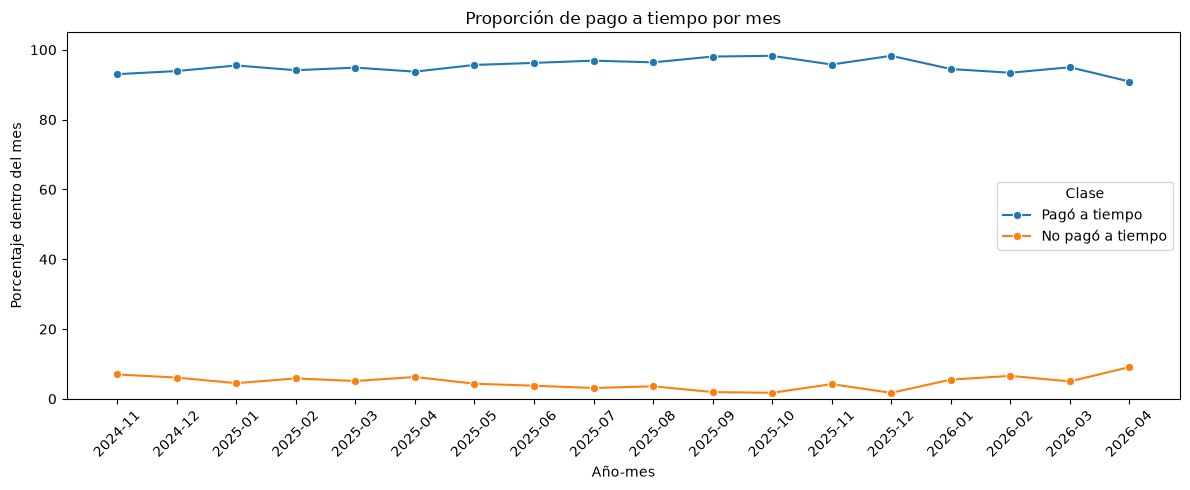

In [64]:
# ============================================================
# 29. Visualización de proporción de pago a tiempo por mes
# ============================================================
pago_por_mes_pivot = pago_por_mes.pivot(
    index="anio_mes",
    columns=target,
    values="porcentaje_dentro_mes"
).reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=pago_por_mes_pivot,
    x="anio_mes",
    y=1,
    marker="o",
    label="Pagó a tiempo"
)
sns.lineplot(
    data=pago_por_mes_pivot,
    x="anio_mes",
    y=0,
    marker="o",
    label="No pagó a tiempo"
)
plt.title("Proporción de pago a tiempo por mes")
plt.xlabel("Año-mes")
plt.ylabel("Porcentaje dentro del mes")
plt.xticks(rotation=45)
plt.ylim(0, 105)
plt.legend(title="Clase")
plt.tight_layout()
plt.show()

### Interpretación visual de proporción de pago a tiempo por mes

El gráfico de proporción mensual muestra que la clase `Pago_atiempo = 1` se mantiene como dominante durante todo el período analizado. En la mayoría de los meses, el porcentaje de clientes que pagaron a tiempo se ubica por encima del 93%.

La clase `Pago_atiempo = 0`, correspondiente a clientes que no pagaron a tiempo, se mantiene en porcentajes bajos durante todo el período. Esto confirma visualmente que el desbalance de la variable objetivo no se concentra en un único momento, sino que se sostiene a lo largo del tiempo.

Se observan algunas variaciones mensuales, especialmente hacia los últimos meses del dataset. Sin embargo, estos períodos tienen menor cantidad de registros, por lo que los cambios porcentuales deben interpretarse con cautela.

Este análisis temporal permite documentar que el comportamiento del target es relativamente estable en el tiempo, aunque el volumen mensual de préstamos sí presenta una caída marcada después del primer semestre de 2025.

### Hallazgos generales del análisis exploratorio

El análisis exploratorio permitió identificar los principales patrones, inconsistencias y puntos de atención del dataset antes de avanzar hacia etapas de limpieza, ingeniería de características y modelado.

En primer lugar, se confirmó que la variable objetivo `Pago_atiempo` presenta un fuerte desbalance. La clase `1`, correspondiente a clientes que pagaron a tiempo, representa la gran mayoría de los registros, mientras que la clase `0` tiene una participación considerablemente menor. Este hallazgo será relevante al momento de entrenar y evaluar modelos, ya que métricas como accuracy podrían resultar engañosas.

También se detectaron valores faltantes en un conjunto reducido de variables. Las columnas con mayor porcentaje de nulos son `tendencia_ingresos` y `promedio_ingresos_datacredito`, ambas con aproximadamente un 27% de datos ausentes. Otras variables relacionadas con saldos y mora presentan porcentajes menores de valores faltantes.

Durante el análisis de variables categóricas se observó que `tipo_laboral` presenta una estructura consistente, con las categorías `Empleado` e `Independiente`. En cambio, `tendencia_ingresos` muestra inconsistencias, ya que además de las categorías esperadas (`Creciente`, `Decreciente` y `Estable`) aparecen valores numéricos que no corresponden conceptualmente con una variable categórica.

En las variables numéricas se identificaron posibles valores extremos o inconsistentes. Algunos ejemplos relevantes son edades cercanas a 120 años, valores negativos en variables de puntaje y montos monetarios extremadamente altos en variables como `salario_cliente`, `total_otros_prestamos`, `cuota_pactada` y `promedio_ingresos_datacredito`.

La matriz de correlación mostró una relación muy alta entre `puntaje` y `Pago_atiempo`, con una correlación aproximada de 0.92. Este hallazgo sugiere que `puntaje` podría ser una variable altamente predictiva, aunque deberá revisarse cuidadosamente para descartar una posible fuga de información o dependencia demasiado cercana al resultado final.

Desde el punto de vista temporal, se observó que la mayor concentración de préstamos se encuentra en 2025. Los años 2024 y 2026 aparecen incompletos dentro del dataset. Además, el volumen mensual de préstamos disminuye progresivamente luego del primer semestre de 2025. A pesar de esta caída en volumen, la proporción de clientes que pagan a tiempo se mantiene alta durante todo el período analizado.

### Consideraciones para la etapa posterior de limpieza e ingeniería de características

A partir de los hallazgos anteriores, se identifican las siguientes acciones potenciales para una etapa posterior de tratamiento de datos:

* Evaluar el tratamiento de valores nulos en `tendencia_ingresos`, `promedio_ingresos_datacredito`, `saldo_mora_codeudor`, `saldo_principal`, `saldo_mora`, `saldo_total` y `puntaje_datacredito`.
* Revisar la columna `tendencia_ingresos`, ya que contiene valores numéricos inconsistentes dentro de una variable categórica.
* Analizar posibles valores atípicos en variables monetarias como `salario_cliente`, `total_otros_prestamos`, `capital_prestado`, `cuota_pactada` y `promedio_ingresos_datacredito`.
* Revisar registros con edades extremadamente altas, especialmente valores cercanos a 120 años.
* Evaluar valores negativos o inusuales en `puntaje` y `puntaje_datacredito`.
* Analizar cuidadosamente la variable `puntaje` por su alta correlación con `Pago_atiempo`, verificando si representa una señal válida para el modelo o si podría implicar fuga de información.
* Considerar la creación de variables derivadas a partir de `fecha_prestamo`, como año, mes o período, si resultan útiles para el modelado.
* Evaluar la necesidad de escalamiento o transformación de variables numéricas, especialmente en modelos sensibles a la escala.
* Definir estrategias de evaluación adecuadas para un problema con target desbalanceado, priorizando métricas como precision, recall, F1-score, matriz de confusión y ROC-AUC.

Estas acciones no se aplican en el presente notebook, ya que el objetivo de esta etapa es comprender y documentar el estado inicial de los datos. El tratamiento formal deberá implementarse posteriormente en la etapa de limpieza e ingeniería de características.
